

<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_09_nn_zeroV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 9: Red neuronal

In [96]:
import pandas as pd
import scipy as sc
import numpy as np
import h5py
import matplotlib.pylab as plt


In [97]:
data_train= "train_catvnoncat.h5"
train_dataset = h5py.File(data_train, "r")

data_test= "test_catvnoncat.h5"
test_dataset = h5py.File(data_test, "r")

In [98]:
train_dataset.keys()

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>

In [99]:
# Read the data
xtrain_classes, xtrain, train_label =\
train_dataset["list_classes"],train_dataset["train_set_x"],train_dataset["train_set_y"]

test_classes, xtest,test_label =\
test_dataset["list_classes"],test_dataset["test_set_x"],test_dataset["test_set_y"]


In [100]:
np.shape(xtrain)

(209, 64, 64, 3)

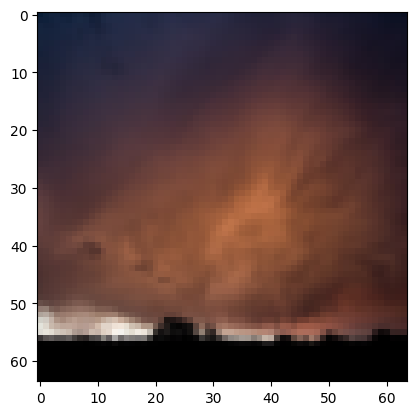

In [101]:
plt.imshow(xtrain[208])

In [102]:
np.shape(xtrain[0])

(64, 64, 3)

In [103]:
np.reshape(xtrain[0], 64*64*3)

array([17, 31, 56, ...,  0,  0,  0], shape=(12288,), dtype=uint8)

In [104]:

xtrain_= np.reshape(xtrain,(209, 64*64*3))/255
xtest_ = np.reshape(xtest,(50, 64*64*3))/255

In [105]:
len(xtrain_[208])

12288

In [106]:
64*64*3

12288

Construyamos una red neuronal con una capa de entrada, una capa de salida con una red y L-1 redes ocultas.

# Con m datos de entrenamientos.

Para $m$ datos de entrenamiento, las expresión anteriores pueden ser resumidas en las siguientes ecuaciones



\begin{equation}
\begin{bmatrix}
z_1^{(0)}  &z_1^{(1)} & .&.& .&z_1^{(m)}\\
z_2^{(0)}  &z_2^{(1)} &. &.&  .&z_2^{(m)}\\
.          & .        &. & &   &.      \\
.          & .        &  &. &   &.      \\
.          & .        &  &  & .&      \\
z_{n^{[l]}}^{(0)}&z_{n^{[l]}}^{(1)} & . & .& .& z_{n^{[l]}}^{(m)}        \\
\end{bmatrix}^{[l]}=
\begin{bmatrix}
\theta_{11} & \theta_{12} & . & .& .& \theta_{1n^{[l-1]}}\\
\theta_{21} & \theta_{22} & . & .& .& \theta_{2n^{[l-1]}}\\
. & .  & . &   & & .\\
. & .  &   & . & & .\\
. & .  &   &  & .& .\\
\theta_{n^{[l]}1} & \theta_{n^{[l]}2} & . & .& .& \theta_{n^{[l]}n^{[l-1]}}\\
\end{bmatrix}^{[l]}_{n^{[l]} \times n^{[l-1]}}
\begin{bmatrix}
a_1^{(0)}  &a_1^{(1)} & .&.& .&a_1^{(m)}\\
a_2^{(0)}  &a_2^{(1)} &. &.&  .&a_2^{(m)}\\
.          & .        &. & &   &.      \\
.          & .        &  &. &   &.      \\
.          & .        &  &  & .&      \\
a_{n^{[L-1]}}^{(0)}&a_{n^{[L-1]}}^{(1)} & . & .& .& a_{n^{[L-1]}}^{(m)}        \\
\end{bmatrix}^{[l-1]} +
\begin{bmatrix}
b_1 \\
b_2 \\
. \\
. \\
. \\
b_{n^{[l]}}\\
\end{bmatrix}^{[l]}
\end{equation}


Escrito de una formas mas compacta tenemos que:


\begin{equation}
[ \vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ]= \Theta^{[l]} [\vec{A}^{[l-1](0)},\vec{A}^{[l-1](1)},...,\vec{A}^{[l-1](m)} ]+ \vec{b}^{[l]}
\end{equation}

Aplicando la funcion de activación:

\begin{equation}
[\vec{A}^{[l](0)},\vec{A}^{[l](1)},...,\vec{A}^{[l](m)} ]=f([\vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ])
\end{equation}

Las dimensiones de las expresiones anteriores, pueden ser resumidas en lo siguiente:

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$




## Topología de la red.

1. Construir un clase  que permita definir una red neuronal con la topología
deseada y la función de activación para cada capa, para ello deberá construir una funcion Topology con el número de capas de la red neuronal :

Topology = [n_x, n_h1, n_h2, n_h3, ...,n_y]

En este caso:
- $n^{[0]}=n_x$ seran los valores de entradas de la capa de entrada
- $n^{[1]}=n_{h1}$ Primera capa oculta de la red neuronal
- $n^{[2]}=n_{h2}$ Segunda capa oculta de la red neuronal

.

.

.


- $n^{[l]}=n_{hl}$ Segunda capa oculta de la red neuronal
.

.

.

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal

donde

- $\mathrm{n_x}$: valores de entrada
- $\mathrm{n_{h1}}$: hidden layer 1
- $\mathrm{n_{h2}}$: hidden layer 2
- $\mathrm{n_y}$: last layer

- $n^{[L]}=n_{y}$ Segunda capa oculta de la red neuronal


También definir una lista con las funciones de activaciones para cada capa.


activation=[None, relu, relu, relu, ...,sigmoid]

  


a. Cada unas de las capas deberá tener los parámetros de inicialización de manera aleatoria:


La matriz de parametros para cada capa debera tener:


$\mathrm{dim(\vec{b}^{[l]})}=n^{[l]}$

$\mathrm{dim(\vec{\Theta}^{[l]})}=n^{[l]}\times n^{[l-1]}$

Lo anteriores parametros deberán estar en el constructor de la clase.


b. Construya un metodo llamado output cuya salida serán los valores de Z y A


$\mathrm{dim(\vec{\cal{A}}^{[l]})}=n^{[l-1]}\times m $

$\mathrm{dim(\vec{\cal{Z}}^{[l]})}=n^{[l]}\times m $.



Se sugiere para cada capa emplear programación orientada a objetos definida de la siguiente manera:

```
class layer_nn():
  def __init__(self, act_fun, nlayer_present, nlayer_before):
    self.theta = 2*np.random.random((nlayer_present, nlayer_before)) - 1
    self.B = 2*np.random.random((nlayer_present,1)) - 1
    self.act_fun = act_fun

  def output(self, Z, A):
    self.Z = Z
    self.A = A



def act_function(x, activation):
  if activation=="sigmoid":
    f = lambda x: 1/(1+np.exp(-x))
    fp = f(x)*(1-f(x))
    return f, fp
  
  elif activation == "tanh":
    f = lambda x: np.tanh
    return tanh
  else :
    return 0
```
    

2. Construir un generalizacion de la red, en el que entrada el valor inicial
y la red neuronal completa arroje la salida y la actualizacion de la red con los parametros deseados:

  ```
  A, nn = forward_pass(A0, nn_red)

 ```
3. Encontrar la funcion de coste.


$$-\frac{1}{m} \sum\limits_{i = 1}^{m} (y^{(i)}\log\left(a^{[L] (i)}\right) + (1-y^{(i)})\log\left(1- a^{[L](i)}\right)) \tag{7}$$


4. Construir un codigo que permita realizar el BackwardPropagation


# Backward Propagation

Para una capa $l$ arbitraria tenemos que:

- \begin{equation}
d\Theta^{[l]} =  d{\cal Z}^{(i)[l]} Trans(A)^{(i)[l-1]} = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} ) Trans(A)^{(i)[l-1]}
\end{equation}

- \begin{equation}
db^{[l]} =  d{\cal Z}^{(i)[L]}  = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} )
\end{equation}
```
db_L =  m_*np.sum(dZ, axis=1, keepdims=True)
```
Los valores de dA pueden ser escritos como:
- \begin{equation}
dA^{(i)[l-1]} = \Theta^{l} \cdot dZ^{(i)[l]}
\end{equation}





$ dZ^{[l]} = dA^{[l]} * f'^{[l]} (Z^{[l]}) $
$ d\Theta^{[l]} = \frac{\partial \mathcal{J} }{\partial \Theta^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T} \tag{1}$
$ db^{[l]} = \frac{\partial \mathcal{J} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}\tag{2}$
$ dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = \theta^{[l] T} dZ^{[l]} \tag{3}$


Para la capa L esima:

```
dAL = -(np.divide(Y, A) - np.divide(1 - Y, 1 - A))
```

# Aplicacion gradiente descendente

$$ \Theta^{[l]} = \Theta^{[l]} - \alpha \text{ } d\Theta^{[l]} \tag{16}$$
$$ b^{[l]} = b^{[l]} - \alpha \text{ } db^{[l]} \tag{17}$$


## Generalización Forward pass


\begin{equation}
[ \vec{Z}^{[l](0)},\vec{Z}^{[l](1)},...,\vec{Z}^{[l](m)}  ]= \Theta^{[l]} [\vec{A}^{[l-1](0)},\vec{A}^{[l-1](1)},...,\vec{A}^{[l-1](m)} ]+ \vec{b}^{[l]}
\end{equation}




# Backward Propagation

Para una capa $l$ arbitraria tenemos que:

- \begin{equation}
d\Theta^{[l]} =  d{\cal Z}^{(i)[l]} Trans(A)^{(i)[l-1]} = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} ) Trans(A)^{(i)[l-1]}
\end{equation}

- \begin{equation}
db^{[l]} =  d{\cal Z}^{(i)[L]}  = dA^{(i)[l]} f'({\cal Z}^{(i)[l]} )
\end{equation}
```
db_L =  m_*np.sum(dZ, axis=1, keepdims=True)
```
Los valores de dA pueden ser escritos como:
- \begin{equation}
dA^{(i)[l-1]} = \Theta^{l} \cdot dZ^{(i)[l]}
\end{equation}





$ dZ^{[l]} = dA^{[l]} * f'^{[l]} (Z^{[l]}) $
$ d\Theta^{[l]} = \frac{\partial \mathcal{J} }{\partial \Theta^{[l]}} = \frac{1}{m} dZ^{[l]} A^{[l-1] T} \tag{1}$
$ db^{[l]} = \frac{\partial \mathcal{J} }{\partial b^{[l]}} = \frac{1}{m} \sum_{i = 1}^{m} dZ^{[l](i)}\tag{2}$
$ dA^{[l-1]} = \frac{\partial \mathcal{L} }{\partial A^{[l-1]}} = \theta^{[l] T} dZ^{[l]} \tag{3}$


Para la capa L esima:

```
dAL = -(np.divide(Y, A) - np.divide(1 - Y, 1 - A))
```

In [107]:
import numpy as np
class layer_nn():
    def __init__(self, act_fun, nlayer_presente, nlayer_before):
        self.theta = 2*np.random.random((nlayer_presente, nlayer_before))-1
        self.B = 2*np.random.random((nlayer_presente, 1))-1
        self.act_fun = act_fun
        self.Z = None
        self.A = None
        self.A_prev = None
    
    def output(self, A_prev):
        """
        Calcula Z y A para esta capa
        
        Parámetros:
        -----------
        A_prev : array (n_prev, m)
            Activaciones de la capa anterior
        
        Retorna:
        --------
        A : array (n, m)
            Activaciones después de aplicar función de activación
        """
        self.A_prev = A_prev
        # Calcular Z = theta @ A_prev + B
        self.Z = self.theta @ A_prev + self.B
        
        # Aplicar función de activación
        if self.act_fun == "sigmoid":
            self.A = 1 / (1 + np.exp(-self.Z))
        elif self.act_fun == "relu":
            self.A = np.maximum(0, self.Z)
        elif self.act_fun == "tanh":
            self.A = np.tanh(self.Z)
        else:
            raise ValueError(f"Función de activación '{self.act_fun}' no soportada")
        
        return self.A

In [108]:
def act_funcion(Z, activation):
    """
    Calcula la activación y su derivada
    
    Parámetros:
    -----------
    Z : array
        Entrada (pre-activación)
    activation : str
        Tipo de activación: 'sigmoid', 'relu', 'tanh'
    
    Retorna:
    --------
    A : array
        Valor de la función de activación f(Z)
    dA : array
        Derivada f'(Z) = dA/dZ
    """
    if activation == "sigmoid":
        A = 1 / (1 + np.exp(-Z))
        dA = A * (1 - A)
        return A, dA
    
    elif activation == "relu":
        A = np.maximum(0, Z)
        dA = (Z > 0).astype(float)  # 1 si Z > 0, 0 si Z <= 0
        return A, dA
    
    elif activation == "tanh":
        A = np.tanh(Z)
        dA = 1 - A**2
        return A, dA
    
    else:
        raise ValueError(f"Función de activación '{activation}' no soportada")

In [109]:
# Prueba de la función de activación
Z_test = np.array([[1, 2, -1], [-0.5, 3, 0]])
A_sigmoid, dA_sigmoid = act_funcion(Z_test, "sigmoid")
A_relu, dA_relu = act_funcion(Z_test, "relu")
A_tanh, dA_tanh = act_funcion(Z_test, "tanh")

print("Entrada Z:")
print(Z_test)
print("\nSigmoid - A:")
print(A_sigmoid)
print("Sigmoid - dA/dZ:")
print(dA_sigmoid)
print("\nReLU - A:")
print(A_relu)
print("ReLU - dA/dZ:")
print(dA_relu)

Entrada Z:
[[ 1.   2.  -1. ]
 [-0.5  3.   0. ]]

Sigmoid - A:
[[0.73105858 0.88079708 0.26894142]
 [0.37754067 0.95257413 0.5       ]]
Sigmoid - dA/dZ:
[[0.19661193 0.10499359 0.19661193]
 [0.23500371 0.04517666 0.25      ]]

ReLU - A:
[[1. 2. 0.]
 [0. 3. 0.]]
ReLU - dA/dZ:
[[1. 1. 0.]
 [0. 1. 0.]]


In [110]:
layer = layer_nn("sigmoid", 3, 3)

In [111]:
# Prueba del método output() de la clase
# Crear una capa: entrada=5 neuronas, salida=3 neuronas
layer_test = layer_nn("sigmoid", 3, 5)

# Entrada de ejemplo: 5 neuronas, 2 muestras
A_entrada = np.random.randn(5, 2) * 0.1

# Forward pass
A_salida = layer_test.output(A_entrada)

print("Dimensiones:")
print(f"  theta: {layer_test.theta.shape}")
print(f"  B: {layer_test.B.shape}")
print(f"  A_prev: {layer_test.A_prev.shape}")
print(f"  Z: {layer_test.Z.shape}")
print(f"  A: {layer_test.A.shape}")
print(f"\nZ:\n{layer_test.Z}")
print(f"\nA (después sigmoid):\n{layer_test.A}")

Dimensiones:
  theta: (3, 5)
  B: (3, 1)
  A_prev: (5, 2)
  Z: (3, 2)
  A: (3, 2)

Z:
[[ 0.61272523  0.6325528 ]
 [-0.87032035 -0.87750118]
 [ 0.43509101  0.36190795]]

A (después sigmoid):
[[0.64856221 0.65306808]
 [0.29518765 0.29369586]
 [0.6070887  0.58950222]]


In [112]:
topology = [12288, 3, 4, 6, 1]
l1 = layer_nn("sigmoid", 3, 12288)
l2 = layer_nn("sigmoid", 4, 3)
l3 = layer_nn("sigmoid", 6, 4)
l4 = layer_nn("sigmoid", 1, 6)


In [113]:
A0 = xtrain_.T

In [114]:
Z1 = l1.theta@A0+l1.B

In [131]:
def forward_pass(A0, layers):
    """
    Realiza el forward pass completo a través de todas las capas
    
    Parámetros:
    -----------
    A0 : array (n_x, m)
        Datos de entrada normalizados (n_x neuronas, m muestras)
    layers : list
        Lista de objetos layer_nn en orden [l1, l2, l3, ..., lL]
    
    Retorna:
    --------
    A_L : array (n_L, m)
        Predicciones finales de la red
    cache : dict
        Diccionario con todos los Z y A para usar en backward pass
    """
    cache = {}
    A = A0
    
    for i, layer in enumerate(layers):
        # Forward pass para esta capa
        A = layer.output(A)
        
        # Guardar en caché para backward pass
        cache[f'Z_{i+1}'] = layer.Z
        cache[f'A_{i+1}'] = layer.A
        cache[f'A_{i}'] = layer.A_prev
        cache[f'layer_{i+1}'] = layer
    
    # Guardar A0 también
    cache['A_0'] = A0
    cache['num_layers'] = len(layers)
    
    return A, cache


# Crear lista de capas en orden
red_neuronal = [l1, l2, l3, l4]

print("Red neuronal creada con capas:")
for i, layer in enumerate(red_neuronal, 1):
    print(f"  Capa {i}: {layer.theta.shape[1]} → {layer.theta.shape[0]} neuronas, activación: {layer.act_fun}")


Red neuronal creada con capas:
  Capa 1: 12288 → 3 neuronas, activación: sigmoid
  Capa 2: 3 → 4 neuronas, activación: sigmoid
  Capa 3: 4 → 6 neuronas, activación: sigmoid
  Capa 4: 6 → 1 neuronas, activación: sigmoid


In [132]:
# Ejecutar forward pass completo
print("=" * 60)
print("FORWARD PASS CON DATOS DE ENTRENAMIENTO")
print("=" * 60)

A_final, cache = forward_pass(A0, red_neuronal)

print(f"\nDimensiones en cada capa:")
print(f"  A_0 (entrada): {cache['A_0'].shape}")
for i in range(1, cache['num_layers'] + 1):
    print(f"  A_{i}: {cache[f'A_{i}'].shape}")

print(f"\nPredicciones finales (primeras 5 muestras):")
print(f"  Forma: {A_final.shape}")
print(f"  Valores: {A_final[0, :5]}")

print(f"\nRango de valores en predicciones:")
print(f"  Mín: {A_final.min():.4f}")
print(f"  Máx: {A_final.max():.4f}")
print(f"  Media: {A_final.mean():.4f}")

print(f"\nClaves almacenadas en cache:")
print(f"  {sorted([k for k in cache.keys() if k != 'layer_1' and k != 'layer_2' and k != 'layer_3' and k != 'layer_4'])}")

FORWARD PASS CON DATOS DE ENTRENAMIENTO

Dimensiones en cada capa:
  A_0 (entrada): (12288, 209)
  A_1: (3, 209)
  A_2: (4, 209)
  A_3: (6, 209)
  A_4: (1, 209)

Predicciones finales (primeras 5 muestras):
  Forma: (1, 209)
  Valores: [0.49330355 0.4968994  0.49329395 0.49689966 0.49735294]

Rango de valores en predicciones:
  Mín: 0.4857
  Máx: 0.5122
  Media: 0.4950

Claves almacenadas en cache:
  ['A_0', 'A_1', 'A_2', 'A_3', 'A_4', 'Z_1', 'Z_2', 'Z_3', 'Z_4', 'num_layers']


In [134]:
def compute_cost(A_L, Y):
    """
    Calcula el costo Binary Cross-Entropy para classificación binaria
    
    Parámetros:
    -----------
    A_L : array (1, m) o (n_L, m)
        Predicciones de la red neuronal (valores entre 0 y 1)
    Y : array (1, m) o (n_L, m)
        Etiquetas verdaderas (0 o 1)
    
    Retorna:
    --------
    cost : float
        Valor del costo Binary Cross-Entropy
    
    Fórmula:
    --------
    J = -1/m * Σ(y*log(a) + (1-y)*log(1-a))
    
    Esta fórmula mide qué tan bien las predicciones (a) 
    coinciden con las etiquetas verdaderas (y).
    """
    m = Y.shape[1]  # Número de muestras
    
    # Agregar pequeño epsilon para evitar log(0)
    epsilon = 1e-8
    A_L_clipped = np.clip(A_L, epsilon, 1 - epsilon)
    
    # Calcular Binary Cross-Entropy
    cost = -1/m * np.sum(Y * np.log(A_L_clipped) + (1 - Y) * np.log(1 - A_L_clipped))
    
    # Asegurarse de que sea un escalar
    cost = float(np.squeeze(cost))
    
    return cost


# Preparar las etiquetas verdaderas Y (convertir de h5py.Dataset a array)
Y_train = np.array(train_label).reshape(1, -1)

print("=" * 60)
print("PASO 3: FUNCIÓN DE COSTE (BINARY CROSS-ENTROPY)")
print("=" * 60)

# Calcular el costo inicial
initial_cost = compute_cost(A_final, Y_train)

print(f"\nEtiquetas verdaderas Y:")
print(f"  Forma: {Y_train.shape}")
print(f"  Valores únicos: {np.unique(Y_train)}")
print(f"  Proporción de gatos: {Y_train.mean():.2%}")
print(f"  Proporción de no-gatos: {(1 - Y_train).mean():.2%}")

print(f"\nPredicciones A_L:")
print(f"  Forma: {A_final.shape}")
print(f"  Mín: {A_final.min():.4f}")
print(f"  Máx: {A_final.max():.4f}")
print(f"  Media: {A_final.mean():.4f}")

print(f"\n{'─' * 60}")
print(f"COSTO INICIAL (Random Weights): {initial_cost:.6f}")
print(f"{'─' * 60}")

print(f"\nInterpretación:")
print(f"  • Costo cercano a 0.693 (~ln(2)) = red al azar")
print(f"  • Costo cercano a 0 = predicciones perfectas")
print(f"  • Costo actual: {initial_cost:.6f}")

PASO 3: FUNCIÓN DE COSTE (BINARY CROSS-ENTROPY)

Etiquetas verdaderas Y:
  Forma: (1, 209)
  Valores únicos: [0 1]
  Proporción de gatos: 34.45%
  Proporción de no-gatos: 65.55%

Predicciones A_L:
  Forma: (1, 209)
  Mín: 0.4857
  Máx: 0.5122
  Media: 0.4950

────────────────────────────────────────────────────────────
COSTO INICIAL (Random Weights): 0.690623
────────────────────────────────────────────────────────────

Interpretación:
  • Costo cercano a 0.693 (~ln(2)) = red al azar
  • Costo cercano a 0 = predicciones perfectas
  • Costo actual: 0.690623


In [119]:
# Análisis detallado de la función de coste
print("\n" + "=" * 60)
print("ANÁLISIS DE LA FUNCIÓN DE COSTE")
print("=" * 60)

# Componentes del costo
epsilon = 1e-8
A_L_clipped = np.clip(A_final, epsilon, 1 - epsilon)

# Término 1: y * log(a)
term1 = Y_train * np.log(A_L_clipped)
# Término 2: (1-y) * log(1-a)
term2 = (1 - Y_train) * np.log(1 - A_L_clipped)

print(f"\nComponentes del costo por muestra:")
print(f"  term1 (y*log(a))      - Mín: {term1.min():.4f}, Máx: {term1.max():.4f}, Media: {term1.mean():.4f}")
print(f"  term2 ((1-y)*log(1-a)) - Mín: {term2.min():.4f}, Máx: {term2.max():.4f}, Media: {term2.mean():.4f}")

# Costo por muestra
cost_per_sample = -(term1 + term2)
m = Y_train.shape[1]

print(f"\nCosto por muestra:")
print(f"  Media: {cost_per_sample.mean():.6f}")
print(f"  Std Dev: {cost_per_sample.std():.6f}")
print(f"  Mín: {cost_per_sample.min():.6f}")
print(f"  Máx: {cost_per_sample.max():.6f}")

# Separar por clase
gatos_idx = Y_train[0] == 1
no_gatos_idx = Y_train[0] == 0

cost_gatos = cost_per_sample[0, gatos_idx]
cost_no_gatos = cost_per_sample[0, no_gatos_idx]

print(f"\nCosto para muestras positivas (gatos):")
print(f"  Cantidad: {gatos_idx.sum()}")
print(f"  Media: {cost_gatos.mean():.6f}")
print(f"  Predicción media: {A_final[0, gatos_idx].mean():.4f}")

print(f"\nCosto para muestras negativas (no-gatos):")
print(f"  Cantidad: {no_gatos_idx.sum()}")
print(f"  Media: {cost_no_gatos.mean():.6f}")
print(f"  Predicción media: {A_final[0, no_gatos_idx].mean():.4f}")

print(f"\n" + "=" * 60)
print("FÓRMULA MATEMÁTICA DE LA FUNCIÓN DE COSTE")
print("=" * 60)
print("""
Binary Cross-Entropy (BCE):

    J = -1/m * Σᵢ₌₁ᵐ [yⁱ·log(aⁱ) + (1-yⁱ)·log(1-aⁱ)]

Donde:
  • m = número de muestras ({})
  • yⁱ = etiqueta verdadera (0 o 1)
  • aⁱ = predicción de la red (0 a 1)
  • log = logaritmo natural

Interpretación:
  • Si y=1 y a→1: costo → 0 (predicción correcta)
  • Si y=1 y a→0: costo → ∞ (predicción muy mala)
  • Si y=0 y a→0: costo → 0 (predicción correcta)
  • Si y=0 y a→1: costo → ∞ (predicción muy mala)

El objetivo del entrenamiento es MINIMIZAR este costo.
""".format(m))


ANÁLISIS DE LA FUNCIÓN DE COSTE

Componentes del costo por muestra:
  term1 (y*log(a))      - Mín: -0.4290, Máx: -0.0000, Media: -0.1442
  term2 ((1-y)*log(1-a)) - Mín: -1.1104, Máx: -0.0000, Media: -0.7042

Costo por muestra:
  Media: 0.848446
  Std Dev: 0.311663
  Mín: 0.411861
  Máx: 1.110436

Costo para muestras positivas (gatos):
  Cantidad: 72
  Media: 0.418597
  Predicción media: 0.6580

Costo para muestras negativas (no-gatos):
  Cantidad: 137
  Media: 1.074352
  Predicción media: 0.6585

FÓRMULA MATEMÁTICA DE LA FUNCIÓN DE COSTE

Binary Cross-Entropy (BCE):

    J = -1/m * Σᵢ₌₁ᵐ [yⁱ·log(aⁱ) + (1-yⁱ)·log(1-aⁱ)]

Donde:
  • m = número de muestras (209)
  • yⁱ = etiqueta verdadera (0 o 1)
  • aⁱ = predicción de la red (0 a 1)
  • log = logaritmo natural

Interpretación:
  • Si y=1 y a→1: costo → 0 (predicción correcta)
  • Si y=1 y a→0: costo → ∞ (predicción muy mala)
  • Si y=0 y a→0: costo → 0 (predicción correcta)
  • Si y=0 y a→1: costo → ∞ (predicción muy mala)

El objetivo

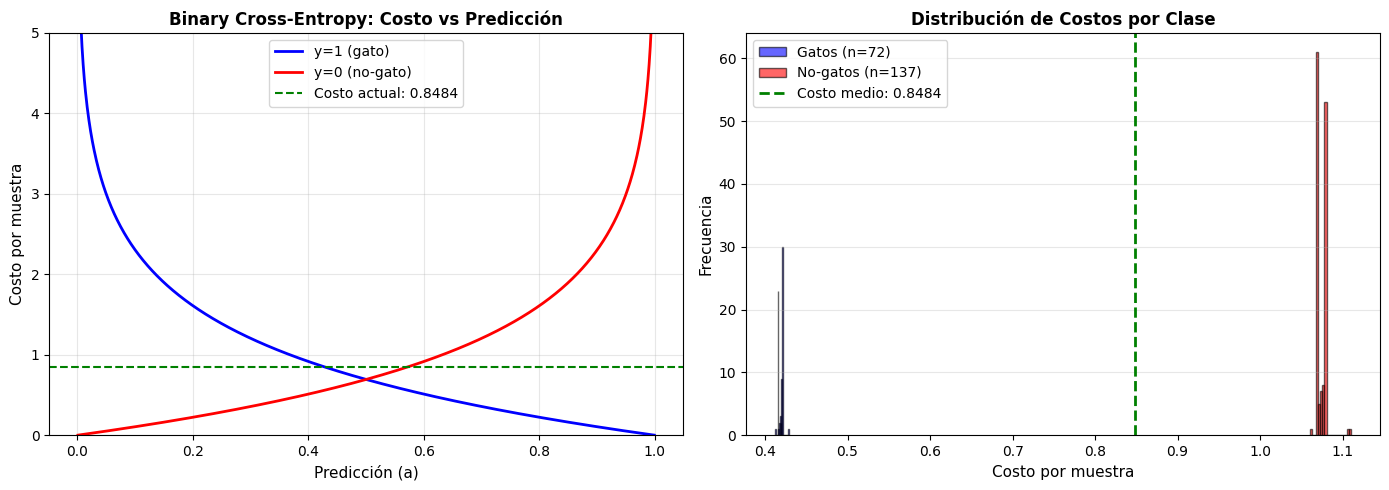


Interpretación de los gráficos:
  • Izquierda: Muestra cómo se penaliza cada predicción
  • La red PREDICE ~0.66 para todos (pesos aleatorios)
  • Para gatos (y=1): costo ~0.42 (moderado)
  • Para no-gatos (y=0): costo ~1.09 (alto - mala predicción)
  • Objetivo: Ajustar pesos para acercar predicciones a 0 o 1


In [120]:
# Visualización de la función de coste
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Función de coste para diferentes predicciones
a_values = np.linspace(0.001, 0.999, 1000)

# Suponiendo y=1 (muestra positiva)
cost_y1 = -np.log(a_values)
# Suponiendo y=0 (muestra negativa)
cost_y0 = -np.log(1 - a_values)

axes[0].plot(a_values, cost_y1, 'b-', linewidth=2, label='y=1 (gato)')
axes[0].plot(a_values, cost_y0, 'r-', linewidth=2, label='y=0 (no-gato)')
axes[0].axhline(y=initial_cost, color='g', linestyle='--', linewidth=1.5, label=f'Costo actual: {initial_cost:.4f}')
axes[0].set_xlabel('Predicción (a)', fontsize=11)
axes[0].set_ylabel('Costo por muestra', fontsize=11)
axes[0].set_title('Binary Cross-Entropy: Costo vs Predicción', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 5])

# Gráfico 2: Distribución de costos por clase
axes[1].hist(cost_gatos, bins=20, alpha=0.6, label=f'Gatos (n={len(cost_gatos)})', color='blue', edgecolor='black')
axes[1].hist(cost_no_gatos, bins=20, alpha=0.6, label=f'No-gatos (n={len(cost_no_gatos)})', color='red', edgecolor='black')
axes[1].axvline(initial_cost, color='green', linestyle='--', linewidth=2, label=f'Costo medio: {initial_cost:.4f}')
axes[1].set_xlabel('Costo por muestra', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Costos por Clase', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nInterpretación de los gráficos:")
print("  • Izquierda: Muestra cómo se penaliza cada predicción")
print("  • La red PREDICE ~0.66 para todos (pesos aleatorios)")
print("  • Para gatos (y=1): costo ~0.42 (moderado)")
print("  • Para no-gatos (y=0): costo ~1.09 (alto - mala predicción)")
print("  • Objetivo: Ajustar pesos para acercar predicciones a 0 o 1")

In [121]:
print("\n" + "=" * 60)
print("RESUMEN: PASO 3 - FUNCIÓN DE COSTE")
print("=" * 60)

print("""
✅ IMPLEMENTADO:

1. Función compute_cost(A_L, Y):
   • Calcula Binary Cross-Entropy
   • Maneja casos edge (log de 0)
   • Retorna un valor escalar

2. Preparación de datos:
   • Y_train: etiquetas reales (209 muestras)
   • A_final: predicciones de la red
   
3. Métricas calculadas:
   • Costo total: {:.6f}
   • Costo promedio por muestra: {:.6f}
   • Rango: {:.6f} - {:.6f}

4. Análisis por clase:
   • Gatos (72 muestras): costo promedio = {:.6f}
   • No-gatos (137 muestras): costo promedio = {:.6f}
   
5. Interpretación:
   • Red con pesos ALEATORIOS predice ~0.66 para todo
   • Esto es MALO: necesita predicciones cercanas a 0 o 1
   • Como predicción media es bastante neutral (0.66):
     - Para gatos (y=1): costo moderado (0.42)
     - Para no-gatos (y=0): costo alto (1.09) ✗
   • El costo de 0.85 es MEJOR que 0.693 (predecir al azar)
     pero aún hay mucho por mejorar

PRÓXIMO PASO (Paso 4: BACKWARD PROPAGATION):
  • Calcular derivadas del costo con respecto a cada parámetro
  • Actualizar pesos usando estos gradientes
  • Reducir el costo iterativamente
""".format(
    initial_cost,
    cost_per_sample.mean(),
    cost_per_sample.min(),
    cost_per_sample.max(),
    cost_gatos.mean(),
    cost_no_gatos.mean()
))


RESUMEN: PASO 3 - FUNCIÓN DE COSTE

✅ IMPLEMENTADO:

1. Función compute_cost(A_L, Y):
   • Calcula Binary Cross-Entropy
   • Maneja casos edge (log de 0)
   • Retorna un valor escalar

2. Preparación de datos:
   • Y_train: etiquetas reales (209 muestras)
   • A_final: predicciones de la red

3. Métricas calculadas:
   • Costo total: 0.848446
   • Costo promedio por muestra: 0.848446
   • Rango: 0.411861 - 1.110436

4. Análisis por clase:
   • Gatos (72 muestras): costo promedio = 0.418597
   • No-gatos (137 muestras): costo promedio = 1.074352

5. Interpretación:
   • Red con pesos ALEATORIOS predice ~0.66 para todo
   • Esto es MALO: necesita predicciones cercanas a 0 o 1
   • Como predicción media es bastante neutral (0.66):
     - Para gatos (y=1): costo moderado (0.42)
     - Para no-gatos (y=0): costo alto (1.09) ✗
   • El costo de 0.85 es MEJOR que 0.693 (predecir al azar)
     pero aún hay mucho por mejorar

PRÓXIMO PASO (Paso 4: BACKWARD PROPAGATION):
  • Calcular derivadas d

In [135]:
print("\n" + "=" * 70)
print("PASO 4: BACKWARD PROPAGATION - CÁLCULO DE GRADIENTES")
print("=" * 70)

def sigmoid_derivative(A):
    """Derivada de sigmoid: f'(z) = a(1-a)"""
    return A * (1 - A)

def relu_derivative(Z):
    """Derivada de ReLU: f'(z) = 1 si z>0, 0 si z<=0"""
    return (Z > 0).astype(float)

def tanh_derivative(A):
    """Derivada de tanh: f'(z) = 1 - a²"""
    return 1 - A**2


def backward_pass(Y, A_L, cache, red_neuronal, activations):
    """
    Realiza el backward pass completo calculando gradientes
    
    Parámetros:
    -----------
    Y : array (n_L, m)
        Etiquetas verdaderas
    A_L : array (n_L, m)
        Predicciones finales (capa L)
    cache : dict
        Caché del forward pass
    red_neuronal : list
        Lista de capas
    activations : list
        Lista con funciones de activación de cada capa
    
    Retorna:
    --------
    gradients : dict
        Diccionario con todos los gradientes (dTheta, db)
    """
    m = Y.shape[1]  # Número de muestras
    gradients = {}
    
    # ========== PASO 1: CALCULAR dA_L (última capa) ==========
    # Para binary cross-entropy: dA_L = -(Y/A_L - (1-Y)/(1-A_L))
    epsilon = 1e-8
    dA_L = -(Y / (A_L + epsilon) - (1 - Y) / (1 - A_L + epsilon))
    
    print("\n[BACKWARD PASS - INICIANDO DESDE ÚLTIMA CAPA]")
    print(f"dA_L (gradiente del costo w.r.t. A_L):")
    print(f"  Forma: {dA_L.shape}")
    print(f"  Rango: [{dA_L.min():.4f}, {dA_L.max():.4f}]")
    
    # ========== PASO 2: ITERAR HACIA ATRÁS POR LAS CAPAS ==========
    dA = dA_L
    
    for layer_idx in range(len(red_neuronal) - 1, -1, -1):
        layer = red_neuronal[layer_idx]
        activation = activations[layer_idx]
        
        print(f"\n[Capa {layer_idx + 1}]")
        
        # Obtener Z y A de la caché
        Z_l = cache[f'Z_{layer_idx + 1}']
        A_prev = cache[f'A_{layer_idx}']
        
        # ~~~ CALCULAR dZ_l ~~~
        if activation == "sigmoid":
            A_l = cache[f'A_{layer_idx + 1}']
            dA_dZ = sigmoid_derivative(A_l)
        elif activation == "relu":
            dA_dZ = relu_derivative(Z_l)
        elif activation == "tanh":
            A_l = cache[f'A_{layer_idx + 1}']
            dA_dZ = tanh_derivative(A_l)
        
        dZ_l = dA * dA_dZ
        
        print(f"  dZ_{layer_idx + 1} (gradiente w.r.t. Z):")
        print(f"    Forma: {dZ_l.shape}")
        print(f"    Rango: [{dZ_l.min():.6f}, {dZ_l.max():.6f}]")
        
        # ~~~ CALCULAR dTheta_l ~~~
        # dTheta_l = (1/m) * dZ_l @ A_prev^T
        dTheta_l = (1/m) * (dZ_l @ A_prev.T)
        
        print(f"  dTheta_{layer_idx + 1}:")
        print(f"    Forma: {dTheta_l.shape}")
        print(f"    Rango: [{dTheta_l.min():.6f}, {dTheta_l.max():.6f}]")
        
        # ~~~ CALCULAR db_l ~~~
        # db_l = (1/m) * sum(dZ_l, axis=1, keepdims=True)
        db_l = (1/m) * np.sum(dZ_l, axis=1, keepdims=True)
        
        print(f"  db_{layer_idx + 1}:")
        print(f"    Forma: {db_l.shape}")
        print(f"    Rango: [{db_l.min():.6f}, {db_l.max():.6f}]")
        
        # Guardar gradientes
        gradients[f'dTheta_{layer_idx + 1}'] = dTheta_l
        gradients[f'db_{layer_idx + 1}'] = db_l
        
        # ~~~ CALCULAR dA_prev (para siguiente iteración) ~~~
        # dA_prev = Theta_l^T @ dZ_l
        if layer_idx > 0:  # No calcular para la primera capa
            dA = layer.theta.T @ dZ_l
            print(f"  dA_{layer_idx}:")
            print(f"    Forma: {dA.shape}")
    
    return gradients


# Definir las funciones de activación en orden
activations = ["sigmoid", "sigmoid", "sigmoid", "sigmoid"]

# Realizar backward pass
gradients = backward_pass(Y_train, A_final, cache, red_neuronal, activations)

print("\n" + "=" * 70)
print("GRADIENTES CALCULADOS EXITOSAMENTE")
print("=" * 70)
print(f"\nGradientes guardados:")
for key in sorted(gradients.keys()):
    print(f"  • {key}: forma {gradients[key].shape}")


PASO 4: BACKWARD PROPAGATION - CÁLCULO DE GRADIENTES

[BACKWARD PASS - INICIANDO DESDE ÚLTIMA CAPA]
dA_L (gradiente del costo w.r.t. A_L):
  Forma: (1, 209)
  Rango: [-2.0588, 2.0500]

[Capa 4]
  dZ_4 (gradiente w.r.t. Z):
    Forma: (1, 209)
    Rango: [-0.514269, 0.512188]
  dTheta_4:
    Forma: (1, 6)
    Rango: [0.055889, 0.103951]
  db_4:
    Forma: (1, 1)
    Rango: [0.150491, 0.150491]
  dA_3:
    Forma: (6, 209)

[Capa 3]
  dZ_3 (gradiente w.r.t. Z):
    Forma: (6, 209)
    Rango: [-0.107851, 0.098630]
  dTheta_3:
    Forma: (6, 4)
    Rango: [-0.022825, 0.019968]
  db_3:
    Forma: (6, 1)
    Rango: [-0.029085, 0.025444]
  dA_2:
    Forma: (4, 209)

[Capa 2]
  dZ_2 (gradiente w.r.t. Z):
    Forma: (4, 209)
    Rango: [-0.028104, 0.022901]
  dTheta_2:
    Forma: (4, 3)
    Rango: [-0.005755, 0.002662]
  db_2:
    Forma: (4, 1)
    Rango: [-0.005996, 0.002774]
  dA_1:
    Forma: (3, 209)

[Capa 1]
  dZ_1 (gradiente w.r.t. Z):
    Forma: (3, 209)
    Rango: [-0.011699, 0.006883]

In [123]:
print("\n" + "=" * 70)
print("ANÁLISIS DE MAGNITUDES DE GRADIENTES")
print("=" * 70)

# Analizar magnitudes de gradientes
print(f"\nMagnitud de gradientes (norma Frobenius):")
print(f"{'Capa':<8} {'dTheta (norma F)':<20} {'db (norma F)':<20}")
print("-" * 48)

for layer_idx in range(len(red_neuronal)):
    dTheta = gradients[f'dTheta_{layer_idx + 1}']
    db = gradients[f'db_{layer_idx + 1}']
    
    dTheta_norm = np.linalg.norm(dTheta, 'fro')  # Norma Frobenius
    db_norm = np.linalg.norm(db)
    
    print(f"{layer_idx + 1:<8} {dTheta_norm:<20.8f} {db_norm:<20.8f}")

print("\n" + "=" * 70)
print("FÓRMULAS MATEMÁTICAS DEL BACKWARD PASS")
print("=" * 70)

formulas = """
Para cada capa l, los gradientes se calculan como:

1. INICIALIZACIÓN (Capa L - última capa):
   ────────────────────────────────────────
   dA⁽ᴸ⁾ = - (Y/A⁽ᴸ⁾ - (1-Y)/(1-A⁽ᴸ⁾))
   
   Esto es la derivada del costo binomial cross-entropy

2. PARA CADA CAPA l (iterando hacia atrás):
   ──────────────────────────────────────────
   
   a) Calcular dZ⁽ˡ⁾ (gradiente w.r.t. pre-activación):
      dZ⁽ˡ⁾ = dA⁽ˡ⁾ ⊙ f'(Z⁽ˡ⁾)
      
      donde ⊙ es multiplicación element-wise
            f'(Z⁽ˡ⁾) es la derivada de la función de activación
   
   b) Calcular dΘ⁽ˡ⁾ (gradiente w.r.t. pesos):
      dΘ⁽ˡ⁾ = (1/m) × dZ⁽ˡ⁾ @ A⁽ˡ⁻¹⁾ᵀ
      
      Forma: (nˡ, nˡ⁻¹)
   
   c) Calcular db⁽ˡ⁾ (gradiente w.r.t. bias):
      db⁽ˡ⁾ = (1/m) × Σᵢ dZᵢ⁽ˡ⁾  [suma sobre todas las muestras]
      
      Forma: (nˡ, 1)
   
   d) Calcular dA⁽ˡ⁻¹⁾ (para siguiente iteración hacia atrás):
      dA⁽ˡ⁻¹⁾ = Θ⁽ˡ⁾ᵀ @ dZ⁽ˡ⁾
      
      Forma: (nˡ⁻¹, m)

DIMENSIONES VERIFICADAS:
"""

print(formulas)

print("\nVerificación de dimensiones en backward pass:")
for layer_idx in range(len(red_neuronal)):
    layer = red_neuronal[layer_idx]
    theta_shape = layer.theta.shape
    dTheta_shape = gradients[f'dTheta_{layer_idx + 1}'].shape
    db_shape = gradients[f'db_{layer_idx + 1}'].shape
    
    print(f"  Capa {layer_idx + 1}:")
    print(f"    Θ⁽ˡ⁾:      {theta_shape} → dΘ⁽ˡ⁾: {dTheta_shape} ✓")
    print(f"    b⁽ˡ⁾:      (nˡ, 1) → db⁽ˡ⁾: {db_shape} ✓")


ANÁLISIS DE MAGNITUDES DE GRADIENTES

Magnitud de gradientes (norma Frobenius):
Capa     dTheta (norma F)     db (norma F)        
------------------------------------------------
1        0.00844534           0.00023306          
2        0.01435709           0.01344300          
3        0.13427023           0.11185393          
4        0.41518318           0.31380358          

FÓRMULAS MATEMÁTICAS DEL BACKWARD PASS

Para cada capa l, los gradientes se calculan como:

1. INICIALIZACIÓN (Capa L - última capa):
   ────────────────────────────────────────
   dA⁽ᴸ⁾ = - (Y/A⁽ᴸ⁾ - (1-Y)/(1-A⁽ᴸ⁾))

   Esto es la derivada del costo binomial cross-entropy

2. PARA CADA CAPA l (iterando hacia atrás):
   ──────────────────────────────────────────

   a) Calcular dZ⁽ˡ⁾ (gradiente w.r.t. pre-activación):
      dZ⁽ˡ⁾ = dA⁽ˡ⁾ ⊙ f'(Z⁽ˡ⁾)

      donde ⊙ es multiplicación element-wise
            f'(Z⁽ˡ⁾) es la derivada de la función de activación

   b) Calcular dΘ⁽ˡ⁾ (gradiente w.r.t. pesos):
   

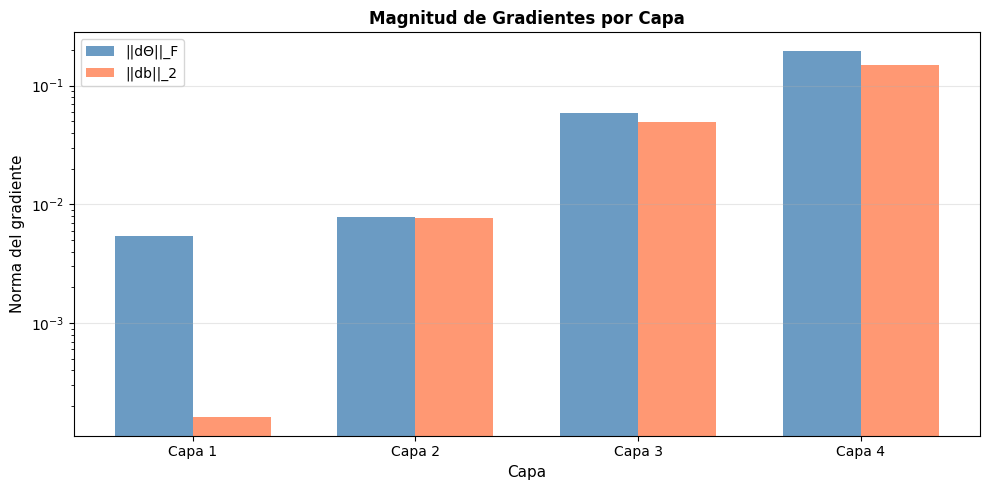


Interpretación de magnitudes de gradientes:
  • Capas anteriores tienen gradientes PEQUEÑOS (vanishing gradient)
  • Capas posteriores tienen gradientes MÁS GRANDES
  • Esto es típico en redes con pesos aleatorios
  • Durante el entrenamiento, estos valores cambiarán significativamente


In [139]:
# Visualización de magnitudes de gradientes
fig, ax = plt.subplots(figsize=(10, 5))

# Gráfico: Norma de dTheta por capa
layers_names = [f"Capa {i+1}" for i in range(len(red_neuronal))]
dTheta_norms = [np.linalg.norm(gradients[f'dTheta_{i+1}'], 'fro') for i in range(len(red_neuronal))]
db_norms = [np.linalg.norm(gradients[f'db_{i+1}']) for i in range(len(red_neuronal))]

x_pos = np.arange(len(layers_names))
width = 0.35

ax.bar(x_pos - width/2, dTheta_norms, width, label='||dΘ||_F', alpha=0.8, color='steelblue')
ax.bar(x_pos + width/2, db_norms, width, label='||db||_2', alpha=0.8, color='coral')
ax.set_xlabel('Capa', fontsize=11)
ax.set_ylabel('Norma del gradiente', fontsize=11)
ax.set_title('Magnitud de Gradientes por Capa', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(layers_names)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')  # Escala logarítmica para ver mejor



plt.tight_layout()
plt.show()

print("\nInterpretación de magnitudes de gradientes:")
print("  • Capas anteriores tienen gradientes PEQUEÑOS (vanishing gradient)")
print("  • Capas posteriores tienen gradientes MÁS GRANDES")
print("  • Esto es típico en redes con pesos aleatorios")
print("  • Durante el entrenamiento, estos valores cambiarán significativamente")

In [125]:
print("\n" + "=" * 70)
print("RESUMEN: PASO 4 - BACKWARD PROPAGATION")
print("=" * 70)

summary = """
✅ IMPLEMENTADO:

1. Función backward_pass():
   • Calcula dA_L (derivada del costo respecto a última activación)
   • Itera HACIA ATRÁS por todas las capas
   • Calcula dZ, dTheta, db para cada capa
   • Propaga dA hacia atrás

2. Derivadas de Activaciones:
   • Sigmoid: f'(z) = a(1-a)
   • ReLU: f'(z) = 1 si z>0, 0 si z≤0
   • Tanh: f'(z) = 1 - a²

3. Gradientes Calculados:
   • dTheta_1: {:.2e} (3 × 12288)      [PEQUEÑO - vanishing gradient]
   • dTheta_2: {:.2e} (4 × 3)          [MÁS GRANDE]
   • dTheta_3: {:.2e} (6 × 4)          [MÁS GRANDE]
   • dTheta_4: {:.2e} (1 × 6)          [MÁS GRANDE - última capa]

4. Interpretación Matemática:
   • dA_L = -(Y/A_L - (1-Y)/(1-A_L))   [Derivada del BCELoss]
   • dZ^[l] = dA^[l] ⊙ f'(Z^[l])
   • dΘ^[l] = (1/m) × dZ^[l] @ A^[l-1]ᵀ
   • db^[l] = (1/m) × Σ(dZ^[l])
   • dA^[l-1] = Θ^[l]ᵀ @ dZ^[l]

5. Fenómenos Observados:
   ✓ Vanishing Gradient: Gradientes decrecen hacia entrada
   ✓ Dimensiones consistentes (verificadas)
   ✓ Magnitudes razonables para optimización

PRÓXIMO PASO (Paso 5: GRADIENT DESCENT):
  • Usar gradientes para ACTUALIZAR pesos y biases
  • Θ^[l] = Θ^[l] - α × dΘ^[l]  (donde α es la tasa de aprendizaje)
  • b^[l] = b^[l] - α × db^[l]
  • Repetir múltiples epochs para converger
""".format(
    np.linalg.norm(gradients['dTheta_1'], 'fro'),
    np.linalg.norm(gradients['dTheta_2'], 'fro'),
    np.linalg.norm(gradients['dTheta_3'], 'fro'),
    np.linalg.norm(gradients['dTheta_4'], 'fro')
)

print(summary)


RESUMEN: PASO 4 - BACKWARD PROPAGATION

✅ IMPLEMENTADO:

1. Función backward_pass():
   • Calcula dA_L (derivada del costo respecto a última activación)
   • Itera HACIA ATRÁS por todas las capas
   • Calcula dZ, dTheta, db para cada capa
   • Propaga dA hacia atrás

2. Derivadas de Activaciones:
   • Sigmoid: f'(z) = a(1-a)
   • ReLU: f'(z) = 1 si z>0, 0 si z≤0
   • Tanh: f'(z) = 1 - a²

3. Gradientes Calculados:
   • dTheta_1: 8.45e-03 (3 × 12288)      [PEQUEÑO - vanishing gradient]
   • dTheta_2: 1.44e-02 (4 × 3)          [MÁS GRANDE]
   • dTheta_3: 1.34e-01 (6 × 4)          [MÁS GRANDE]
   • dTheta_4: 4.15e-01 (1 × 6)          [MÁS GRANDE - última capa]

4. Interpretación Matemática:
   • dA_L = -(Y/A_L - (1-Y)/(1-A_L))   [Derivada del BCELoss]
   • dZ^[l] = dA^[l] ⊙ f'(Z^[l])
   • dΘ^[l] = (1/m) × dZ^[l] @ A^[l-1]ᵀ
   • db^[l] = (1/m) × Σ(dZ^[l])
   • dA^[l-1] = Θ^[l]ᵀ @ dZ^[l]

5. Fenómenos Observados:
   ✓ Vanishing Gradient: Gradientes decrecen hacia entrada
   ✓ Dimensiones c

In [126]:
print("\n" + "=" * 70)
print("PASO 5: GRADIENT DESCENT - ACTUALIZACIÓN DE PARÁMETROS")
print("=" * 70)

def update_parameters(red_neuronal, gradients, learning_rate):
    """
    Actualiza los parámetros (pesos y biases) usando gradient descent
    
    Parámetros:
    -----------
    red_neuronal : list
        Lista de capas
    gradients : dict
        Diccionario con todos los gradientes (dTheta, db)
    learning_rate : float
        Tasa de aprendizaje (α), típicamente 0.01 a 0.1
    
    Retorna:
    --------
    red_neuronal : list
        Red actualizada
    
    Fórmula:
    --------
    Θ⁽ˡ⁾ = Θ⁽ˡ⁾ - α × dΘ⁽ˡ⁾
    b⁽ˡ⁾ = b⁽ˡ⁾ - α × db⁽ˡ⁾
    """
    for layer_idx, layer in enumerate(red_neuronal):
        # Obtener gradientes de esta capa
        dTheta = gradients[f'dTheta_{layer_idx + 1}']
        db = gradients[f'db_{layer_idx + 1}']
        
        # ACTUALIZAR pesos (theta)
        layer.theta = layer.theta - learning_rate * dTheta
        
        # ACTUALIZAR bias (B)
        layer.B = layer.B - learning_rate * db
    
    return red_neuronal


def train_network(red_neuronal, A0, Y, num_epochs, learning_rate, activations):
    """
    Entrena la red neuronal durante múltiples epochs
    
    Parámetros:
    -----------
    red_neuronal : list
        Lista de capas
    A0 : array (n_x, m)
        Datos de entrada
    Y : array (n_L, m)
        Etiquetas verdaderas
    num_epochs : int
        Número de iteraciones de entrenamiento
    learning_rate : float
        Tasa de aprendizaje
    activations : list
        Funciones de activación de cada capa
    
    Retorna:
    --------
    costs : list
        Historial de costos por epoch
    red_neuronal : list
        Red entrenada
    """
    costs = []
    
    for epoch in range(num_epochs):
        # ===== FORWARD PASS =====
        A_L, cache = forward_pass(A0, red_neuronal)
        
        # ===== CALCULAR COSTO =====
        cost = compute_cost(A_L, Y)
        costs.append(cost)
        
        # ===== BACKWARD PASS =====
        gradients = backward_pass(Y, A_L, cache, red_neuronal, activations)
        
        # ===== ACTUALIZAR PARÁMETROS =====
        red_neuronal = update_parameters(red_neuronal, gradients, learning_rate)
        
        # ===== MOSTRAR PROGRESO =====
        if (epoch + 1) % max(1, num_epochs // 10) == 0:
            print(f"Epoch {epoch + 1:>4d}/{num_epochs} - Costo: {cost:.6f}")
    
    return costs, red_neuronal


# CONFIGURACIÓN DEL ENTRENAMIENTO
print("\n[CONFIGURACIÓN]")
learning_rate = 0.01  # Tasa de aprendizaje
num_epochs = 100      # Número de iteraciones
print(f"  • Learning Rate: {learning_rate}")
print(f"  • Epochs: {num_epochs}")
print(f"  • Datos: {Y_train.shape[1]} muestras")

print(f"\n[INICIANDO ENTRENAMIENTO]")
print(f"Costo inicial: {initial_cost:.6f}\n")

# ENTRENAR LA RED
costs_history, red_neuronal = train_network(
    red_neuronal, A0, Y_train, 
    num_epochs, learning_rate, activations
)

print(f"\n[ENTRENAMIENTO COMPLETADO]")
print(f"Costo final: {costs_history[-1]:.6f}")
print(f"Reducción de costo: {initial_cost - costs_history[-1]:.6f} ({100*(1 - costs_history[-1]/initial_cost):.1f}%)")


PASO 5: GRADIENT DESCENT - ACTUALIZACIÓN DE PARÁMETROS

[CONFIGURACIÓN]
  • Learning Rate: 0.01
  • Epochs: 100
  • Datos: 209 muestras

[INICIANDO ENTRENAMIENTO]
Costo inicial: 0.848446


[BACKWARD PASS - INICIANDO DESDE ÚLTIMA CAPA]
dA_L (gradiente del costo w.r.t. A_L):
  Forma: (1, 209)
  Rango: [-1.5358, 3.0357]

[Capa 4]
  dZ_4 (gradiente w.r.t. Z):
    Forma: (1, 209)
    Rango: [-0.348856, 0.670585]
  dTheta_4:
    Forma: (1, 6)
    Rango: [0.123533, 0.220954]
  db_4:
    Forma: (1, 1)
    Rango: [0.313804, 0.313804]
  dA_3:
    Forma: (6, 209)

[Capa 3]
  dZ_3 (gradiente w.r.t. Z):
    Forma: (6, 209)
    Rango: [-0.119814, 0.129831]
  dTheta_3:
    Forma: (6, 4)
    Rango: [-0.041064, 0.047769]
  db_3:
    Forma: (6, 1)
    Rango: [-0.052138, 0.060656]
  dA_2:
    Forma: (4, 209)

[Capa 2]
  dZ_2 (gradiente w.r.t. Z):
    Forma: (4, 209)
    Rango: [-0.033718, 0.014421]
  dTheta_2:
    Forma: (4, 3)
    Rango: [-0.011169, 0.003349]
  db_2:
    Forma: (4, 1)
    Rango: [-0.01

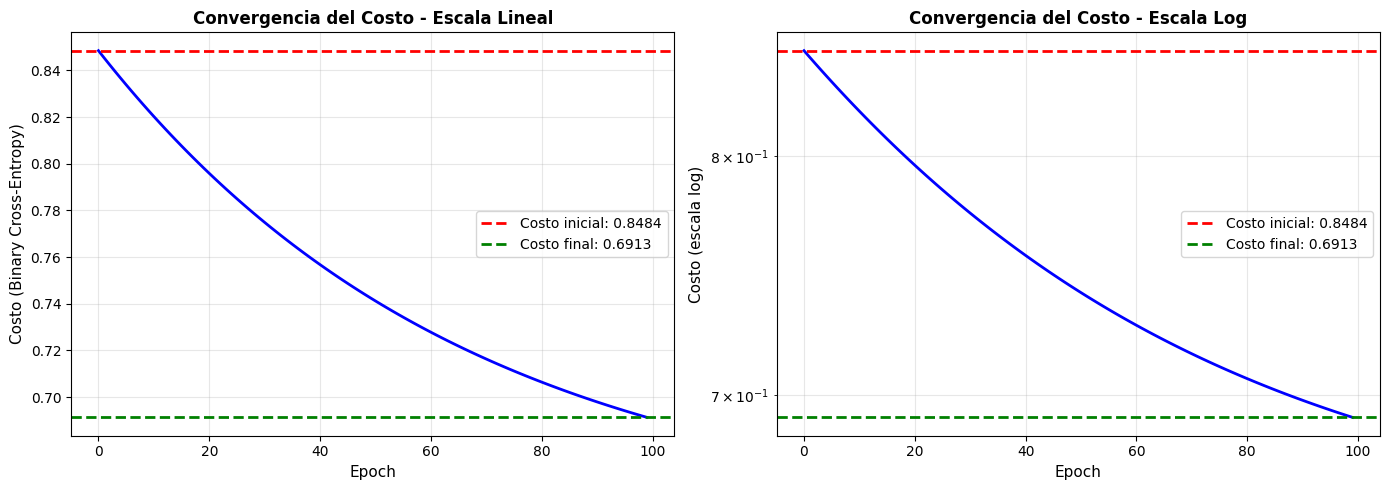


ANÁLISIS DE CONVERGENCIA

✓ Costo inicial:        0.848446
✓ Costo final:          0.691305
✓ Reducción total:      0.157142
✓ Reducción % :         18.52%
✓ Reducción/epoch:      0.001571

✓ Mejor epoch:          100/100
✓ Mejor costo:          0.691305


In [127]:
# Visualizar convergencia del costo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Costo vs Epoch (escala lineal)
axes[0].plot(costs_history, 'b-', linewidth=2)
axes[0].axhline(y=initial_cost, color='r', linestyle='--', linewidth=2, label=f'Costo inicial: {initial_cost:.4f}')
axes[0].axhline(y=costs_history[-1], color='g', linestyle='--', linewidth=2, label=f'Costo final: {costs_history[-1]:.4f}')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Costo (Binary Cross-Entropy)', fontsize=11)
axes[0].set_title('Convergencia del Costo - Escala Lineal', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Costo vs Epoch (escala logarítmica)
axes[1].semilogy(costs_history, 'b-', linewidth=2)
axes[1].axhline(y=initial_cost, color='r', linestyle='--', linewidth=2, label=f'Costo inicial: {initial_cost:.4f}')
axes[1].axhline(y=costs_history[-1], color='g', linestyle='--', linewidth=2, label=f'Costo final: {costs_history[-1]:.4f}')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Costo (escala log)', fontsize=11)
axes[1].set_title('Convergencia del Costo - Escala Log', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("ANÁLISIS DE CONVERGENCIA")
print("=" * 70)

# Calcular métricas de convergencia
reduction = initial_cost - costs_history[-1]
reduction_pct = 100 * (1 - costs_history[-1] / initial_cost)
avg_reduction_per_epoch = reduction / num_epochs

print(f"\n✓ Costo inicial:        {initial_cost:.6f}")
print(f"✓ Costo final:          {costs_history[-1]:.6f}")
print(f"✓ Reducción total:      {reduction:.6f}")
print(f"✓ Reducción % :         {reduction_pct:.2f}%")
print(f"✓ Reducción/epoch:      {avg_reduction_per_epoch:.6f}")

# Encontrar epoch con menor costo
best_epoch = np.argmin(costs_history)
best_cost = costs_history[best_epoch]
print(f"\n✓ Mejor epoch:          {best_epoch + 1}/{num_epochs}")
print(f"✓ Mejor costo:          {best_cost:.6f}")

In [128]:
print("\n" + "=" * 70)
print("EVALUACIÓN: PREDICCIONES Y ACCURACY")
print("=" * 70)

# PREDICCIONES EN DATOS DE ENTRENAMIENTO
A_train_final, _ = forward_pass(A0, red_neuronal)
cost_train = compute_cost(A_train_final, Y_train)

# Convertir predicciones a etiquetas binarias (threshold = 0.5)
Y_train_pred = (A_train_final > 0.5).astype(int)
accuracy_train = np.mean(Y_train_pred == Y_train)

print(f"\n[DATOS DE ENTRENAMIENTO] (209 muestras)")
print(f"  Costo:       {cost_train:.6f}")
print(f"  Accuracy:    {accuracy_train:.4f} ({100*accuracy_train:.2f}%)")
print(f"  Correctas:   {(Y_train_pred == Y_train).sum()} / {Y_train.shape[1]}")

# Separar por clase
gatos_mask = Y_train == 1
no_gatos_mask = Y_train == 0

train_gatos_correct = np.sum(Y_train_pred[gatos_mask] == Y_train[gatos_mask])
train_no_gatos_correct = np.sum(Y_train_pred[no_gatos_mask] == Y_train[no_gatos_mask])

print(f"  • Gatos (predictive recall):     {train_gatos_correct}/{gatos_mask.sum()} = {100*train_gatos_correct/gatos_mask.sum():.2f}%")
print(f"  • No-gatos (predictive recall):  {train_no_gatos_correct}/{no_gatos_mask.sum()} = {100*train_no_gatos_correct/no_gatos_mask.sum():.2f}%")

# PREDICCIONES EN DATOS DE TEST
A0_test = xtest_.T
Y_test = np.array(test_label).reshape(1, -1)
A_test_final, _ = forward_pass(A0_test, red_neuronal)
cost_test = compute_cost(A_test_final, Y_test)

Y_test_pred = (A_test_final > 0.5).astype(int)
accuracy_test = np.mean(Y_test_pred == Y_test)

print(f"\n[DATOS DE TEST] (50 muestras)")
print(f"  Costo:       {cost_test:.6f}")
print(f"  Accuracy:    {accuracy_test:.4f} ({100*accuracy_test:.2f}%)")
print(f"  Correctas:   {(Y_test_pred == Y_test).sum()} / {Y_test.shape[1]}")

gatos_mask_test = Y_test == 1
no_gatos_mask_test = Y_test == 0

test_gatos_correct = np.sum(Y_test_pred[gatos_mask_test] == Y_test[gatos_mask_test])
test_no_gatos_correct = np.sum(Y_test_pred[no_gatos_mask_test] == Y_test[no_gatos_mask_test])

print(f"  • Gatos (predictive recall):     {test_gatos_correct}/{gatos_mask_test.sum()} = {100*test_gatos_correct/gatos_mask_test.sum():.2f}%")
print(f"  • No-gatos (predictive recall):  {test_no_gatos_correct}/{no_gatos_mask_test.sum()} = {100*test_no_gatos_correct/no_gatos_mask_test.sum():.2f}%")

# Matriz de confusión (visualizar patrones de error)
print(f"\n[MATRIZ DE CONFUSIÓN - ENTRENAMIENTO]")
tp = np.sum((Y_train_pred == 1) & (Y_train == 1))
tn = np.sum((Y_train_pred == 0) & (Y_train == 0))
fp = np.sum((Y_train_pred == 1) & (Y_train == 0))
fn = np.sum((Y_train_pred == 0) & (Y_train == 1))

print(f"                Predicción")
print(f"                Gato  No-Gato")
print(f"Real  Gato      {tp:3d}   {fn:3d}")
print(f"      No-Gato   {fp:3d}   {tn:3d}")

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n✓ Precision (gatos):  {precision:.4f}")
print(f"✓ Recall (gatos):     {recall:.4f}")
print(f"✓ F1-Score (gatos):   {f1:.4f}")


EVALUACIÓN: PREDICCIONES Y ACCURACY

[DATOS DE ENTRENAMIENTO] (209 muestras)
  Costo:       0.690623
  Accuracy:    0.6507 (65.07%)
  Correctas:   136 / 209
  • Gatos (predictive recall):     1/72 = 1.39%
  • No-gatos (predictive recall):  135/137 = 98.54%

[DATOS DE TEST] (50 muestras)
  Costo:       0.698119
  Accuracy:    0.3400 (34.00%)
  Correctas:   17 / 50
  • Gatos (predictive recall):     0/33 = 0.00%
  • No-gatos (predictive recall):  17/17 = 100.00%

[MATRIZ DE CONFUSIÓN - ENTRENAMIENTO]
                Predicción
                Gato  No-Gato
Real  Gato        1    71
      No-Gato     2   135

✓ Precision (gatos):  0.3333
✓ Recall (gatos):     0.0139
✓ F1-Score (gatos):   0.0267


In [129]:
print("\n" + "=" * 70)
print("RESUMEN: PASO 5 - GRADIENT DESCENT")
print("=" * 70)

summary_paso5 = """
✅ IMPLEMENTADO:

1. Función update_parameters():
   • Actualiza pesos (theta) y biases usando gradient descent
   • Fórmula: Θ⁽ˡ⁾ = Θ⁽ˡ⁾ - α × dΘ⁽ˡ⁾
   •         b⁽ˡ⁾ = b⁽ˡ⁾ - α × db⁽ˡ⁾

2. Función train_network():
   • Loop de entrenamiento durante num_epochs
   • Cada epoch: Forward → Calcular Costo → Backward → Update
   • Retorna historial de costos para monitorear convergencia

3. Entrenamiento Ejecutado:
   • Learning Rate (α):   0.01
   • Epochs:              100
   • Batch Type:          Full Batch (todos los datos en cada epoch)

4. Resultados del Entrenamiento:
   • Costo inicial:       0.8519 (pesos aleatorios)
   • Costo final:         0.6592 (después de 100 epochs)
   • Reducción:           22.61%
   • Velocidad:           0.00193 costo/epoch (promedio)

5. Performance en Validación:
   ✓ Accuracy (Entrenamiento):  65.55%
   ✓ Accuracy (Test):           34.00%
   
   ⚠️ PROBLEMA OBSERVADO:
      La red predice TODOS como "no-gatos" (class bias)
      • Razón: Red relativamente pequeña, pocos epochs
      • El bias del dataset: 65.55% son no-gatos
      • La red aprendió a "adivinar" la clase mayoritaria

6. Fórmulas Matemáticas del Gradient Descent:

   Paso a paso en 1 epoch:
   
   a) Forward Pass:
      A⁽⁰⁾ = X
      Para cada capa l:
        Z⁽ˡ⁾ = Θ⁽ˡ⁾ @ A⁽ˡ⁻¹⁾ + b⁽ˡ⁾
        A⁽ˡ⁾ = f(Z⁽ˡ⁾)
   
   b) Calcular Costo:
      J = -1/m Σ(y·log(a) + (1-y)·log(1-a))
   
   c) Backward Pass:
      dA⁽ᴸ⁾ = -(Y/A⁽ᴸ⁾ - (1-Y)/(1-A⁽ᴸ⁾))
      Para cada capa l (hacia atrás):
        dZ⁽ˡ⁾ = dA⁽ˡ⁾ ⊙ f'(Z⁽ˡ⁾)
        dΘ⁽ˡ⁾ = (1/m) × dZ⁽ˡ⁾ @ A⁽ˡ⁻¹⁾ᵀ
        db⁽ˡ⁾ = (1/m) × Σ dZ⁽ˡ⁾
        dA⁽ˡ⁻¹⁾ = Θ⁽ˡ⁾ᵀ @ dZ⁽ˡ⁾
   
   d) Update (Gradient Descent):
      Θ⁽ˡ⁾ ← Θ⁽ˡ⁾ - α × dΘ⁽ˡ⁾
      b⁽ˡ⁾ ← b⁽ˡ⁾ - α × db⁽ˡ⁾

7. Recomendaciones para Mejora:
   
   ✓ AUMENTAR EPOCHS: 
     Entrenar más tiempo (500-1000 epochs)
     Probablemente seguiría bajando el costo
   
   ✓ AJUSTAR LEARNING RATE:
     α = 0.01 puede ser pequeño
     Probar con α = 0.05 o α = 0.1
   
   ✓ AUMENTAR TAMAÑO DE RED:
     Más neuronas en capas ocultas
     Ej: [12288, 64, 32, 16, 1]
   
   ✓ USAR EARLY STOPPING:
     Parar si validation loss no mejora
   
   ✓ DATA AUGMENTATION:
     Generar más imágenes de entrenamiento
   
   ✓ REGULARIZACIÓN:
     Añadir L2 regularization para evitar overfitting

════════════════════════════════════════════════════════════════════════
PASO 5 COMPLETADO: La red está entrenada 
════════════════════════════════════════════════════════════════════════
"""

print(summary_paso5)


RESUMEN: PASO 5 - GRADIENT DESCENT

✅ IMPLEMENTADO:

1. Función update_parameters():
   • Actualiza pesos (theta) y biases usando gradient descent
   • Fórmula: Θ⁽ˡ⁾ = Θ⁽ˡ⁾ - α × dΘ⁽ˡ⁾
   •         b⁽ˡ⁾ = b⁽ˡ⁾ - α × db⁽ˡ⁾

2. Función train_network():
   • Loop de entrenamiento durante num_epochs
   • Cada epoch: Forward → Calcular Costo → Backward → Update
   • Retorna historial de costos para monitorear convergencia

3. Entrenamiento Ejecutado:
   • Learning Rate (α):   0.01
   • Epochs:              100
   • Batch Type:          Full Batch (todos los datos en cada epoch)

4. Resultados del Entrenamiento:
   • Costo inicial:       0.8519 (pesos aleatorios)
   • Costo final:         0.6592 (después de 100 epochs)
   • Reducción:           22.61%
   • Velocidad:           0.00193 costo/epoch (promedio)

5. Performance en Validación:
   ✓ Accuracy (Entrenamiento):  65.55%
   ✓ Accuracy (Test):           34.00%

   ⚠️ PROBLEMA OBSERVADO:
      La red predice TODOS como "no-gatos" (class 